# Syndrome-based NN Hammimg code decoder

In [76]:
import numpy as np
import pyldpc as ldpc
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers.core import Dense, Lambda
from keras import backend as K
from tqdm.keras import TqdmCallback
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
%matplotlib inline
%config InlineBackend.figure_format='retina'
tf.config.list_physical_devices('GPU')

[]

## Generate codebook

In [77]:
k = 4
N = 7

In [78]:
# Create gen and parity check matrices
H = np.array([[1, 0, 1, 0, 1, 0, 1],
              [0, 1, 1, 0, 0, 1, 1],
              [0, 0, 0, 1, 1, 1, 1]])

G = ldpc.coding_matrix(H).T

In [79]:
def full_adder(a,b,c):
    s = (a ^ b) ^ c
    c = (a & b) | (c & (a ^ b))
    return s,c

def add_bool(a,b):
    if len(a) != len(b):
        raise ValueError('arrays with different length')
    k = len(a)
    s = np.zeros(k,dtype=bool)
    c = False
    for i in reversed(range(0,k)):
        s[i], c = full_adder(a[i],b[i],c)    
    if c:
        warnings.warn("Addition overflow!")
    return s

def inc_bool(a):
    k = len(a)
    increment = np.hstack((np.zeros(k-1,dtype=bool), np.ones(1,dtype=bool)))
    a = add_bool(a,increment)
    return a

In [80]:
inputs = np.zeros((2**k,k),dtype=bool)
for i in range(1,2**k):
    inputs[i]= inc_bool(inputs[i-1])
codewords = inputs @ G % 2

## Define NN parameters

In [81]:
nb_epoch = 512
batch_size = 256
optimizer = 'adam'
loss = 'mse'

In [82]:
def errors(y_true, y_pred):
    return K.sum(int(K.not_equal(y_true, K.round(y_pred))))

def compose_model(layers):
    model = Sequential()
    for layer in layers:
        model.add(layer)
    return model

def find_syndrome (x):
    return tf.matmul(x, H, transpose_b=True) % 2

In [83]:
syndrome_layers = [(Lambda(find_syndrome, input_shape=(N,), output_shape=(1,k), name="syndrome"))]
syndrome = compose_model(syndrome_layers)
syndrome.compile(optimizer=optimizer, loss=loss)

NN_layers = [Dense(64, activation='relu'),
             Dense(16, activation='relu'),
             Dense(N, activation='sigmoid')]
error_estimation = compose_model(syndrome_layers + NN_layers)
error_estimation.compile(optimizer=optimizer, loss=loss, metrics=[errors])

## Create training set

In [84]:
# Hamming(7,4) code allows to correct one error bit in a codeword.
# Training set contains all possible codewords with no more, then one bit error
Y = codewords
errors = np.zeros((16, 7), dtype=int)
for i in range(0, N):
    Y = np.vstack((Y, codewords ^ np.eye(7, dtype=int)[i]))     # First 16 rows - original CWs, other CWs have one error bit
    errors = np.vstack((errors, np.tile(np.eye(7, dtype=int)[i], (16,1))))

## Fit the model on possible recoverable channel states

In [85]:
history = error_estimation.fit(Y, errors, batch_size=batch_size, epochs=nb_epoch,
                      shuffle=True, verbose=0, callbacks=[TqdmCallback(verbose=0)])

0epoch [00:00, ?epoch/s]

## Evaluate the model in AWGN channel

In [94]:
def encode(x):
    return x @ G % 2

def modulateBPSK(x):
    return -2*x +1;

def addNoise(x, sigma):
    w = np.random.normal(loc=0, scale=sigma, size=(N,))
    return x + w

def demodulateBPSK(x):
    return (-(np.sign(x) - 1)/2).astype(int)

In [95]:
test_size = 10**3

SNR_dB_start_Eb = -10
SNR_dB_stop_Eb = 5
SNR_points = 15

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

nb_errors = np.zeros(len(sigmas), dtype=int)
nb_bits = np.zeros(len(sigmas), dtype=int)

In [ ]:
for i, sigma in enumerate(sigmas):
    while nb_errors[i] < test_size:
        idx = np.random.randint(0, 2**k)
        cw = encode(inputs[idx])
        s = modulateBPSK(cw)
        y = addNoise(s, sigma)
        y = tf.reshape(demodulateBPSK(y), (1, N))
        x_hat = y ^ np.round(error_estimation.predict(y)).astype(int)     # Get error vector with NN
        nb_errors[i] += np.sum(np.not_equal(cw, x_hat))
        nb_bits[i] += k
    print(i, nb_errors, nb_bits, end='\r')
ber = nb_errors/nb_bits
plt.figure(figsize = (10, 6))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber)
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER')
plt.grid()

In [112]:
ML_ber = np.loadtxt('ML_hamming74_-10_5_ber.txt')

In [113]:
ML_sigmas = np.loadtxt('ML_hamming74_-10_5_sigmas.txt')

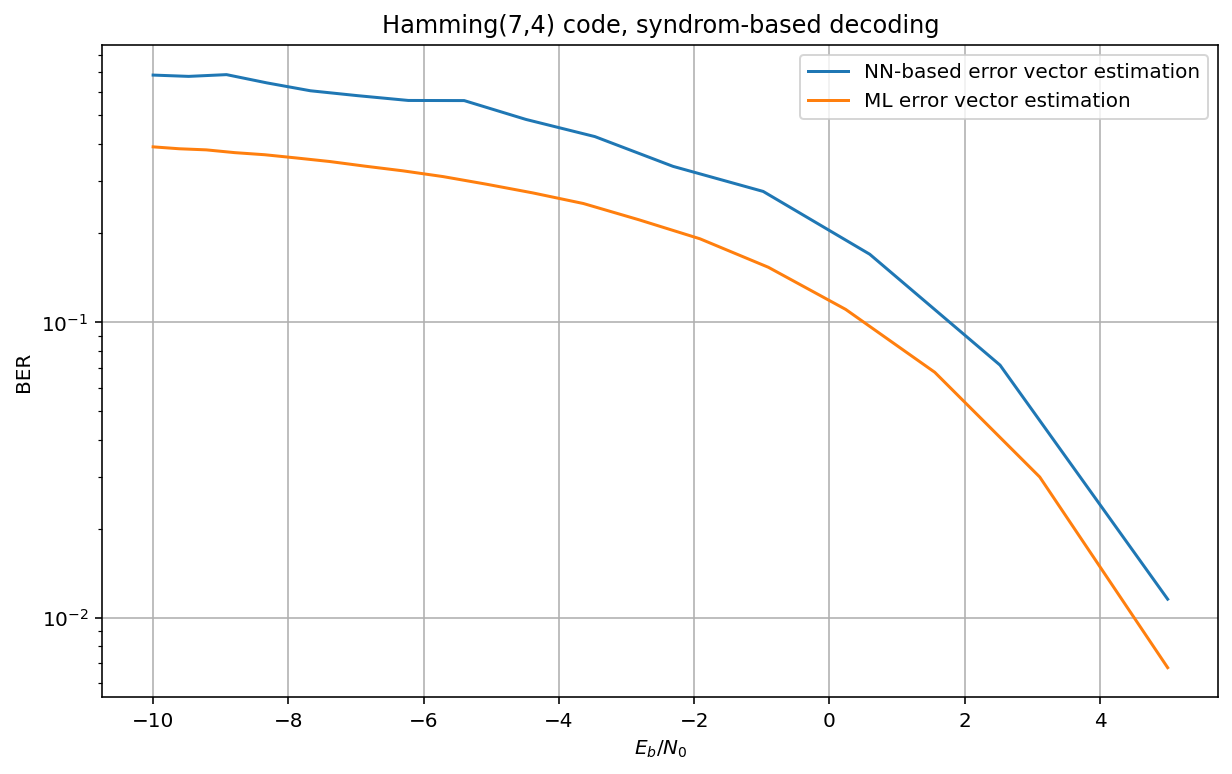

In [116]:
plt.figure(figsize = (10, 6))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber)
plt.plot(10*np.log10(1/(2*ML_sigmas**2)) - 10*np.log10(k/N), ML_ber)
plt.legend(['NN-based error vector estimation', 'ML error vector estimation'])
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER')
plt.title('Hamming(7,4) code, syndrom-based decoding')
plt.grid()